<a href="https://colab.research.google.com/github/iGeology-Illinois/geol-581-module-3-principles-of-uncertainty-chapter-4-ktseiffert/blob/main/geol581_m3statshw.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Question 4.1

A rock slope is to be cut as part of a road construction project. However, there is a risk that the slope could slide along the bedding planes into the excavation pit. In order to carry out a stability analysis it is necessary to estimate the angle of friction along the bedding planes. An initial assessment on the mean value of the friction angle can be obtained from the spectrum of possible manifestations of the friction angle. It cannot be smaller than the base friction angle, i.e. the friction angle that would result on the sawn, smooth surface of a specimen. The base friction angle for the greywackes that make up the slope is about 20°. The maximum possible friction angle can be estimated by back-calculating past failure cases. So far, no friction angle exceeding 35° has been back-calculated. What is the probability that the friction angle is smaller than 25°? Since no further information is available, the PDF of the friction angle can be assumed to be uniform.

In [ ]:
# In this cell, you can begin by importing the libraries you need and setting up a simple
# calculation to handle the uniform distribution between 20 and 35 degrees.
import numpy as np
from scipy import stats

# HINT:
# 1. You can model friction angles as U(20, 35).
# 2. Calculate the probability that the friction angle is below 25 degrees.
# 3. Confirm your result matches the analytical approach: (25 - 20) / (35 - 20).

# You might start coding something like this:
# lower_bound = 20
# upper_bound = 35
# desired_angle = 25
# ...

In [36]:
import numpy as np
from scipy.stats import uniform

lb = 20
ub = 35
des = 25

range = ub - lb

prob = uniform.cdf(des, loc=lb, scale=range)
print("probability friction angle is smaller than 25 deg [scipy] =", prob)

analytical = (des - lb) / (ub - lb)
print("probability friction angle is smaller than 25 deg [analytical] =", analytical)


probability friction angle is smaller than 25 deg [scipy] = 0.3333333333333333
probability friction angle is smaller than 25 deg [analytical] = 0.3333333333333333


# Question 4.2

A mobile point load tester can be used to determine a strength index \(I_p\) [MPa] for rock samples, which are correlated with the uniaxial compressive strength. 25 strength values \(I_p\) were determined for a sandstone sequence:

4.4; 4.2; 4.5; 4.0; 4.3; 4.1; 3.9; 4.2; 4.5; 3.8; 4.0; 4.3; 4.2; 4.2;
4.1; 4.5; 4.2; 4.3; 4.1; 3.7; 4.0; 4.5; 4.6; 4.3; 4.1
(n = 25)

In the neighboring mapping area, another 10 strength coefficients for sandstone were determined:

3.7; 4.5; 4.2; 4.4; 4.3; 4.0; 3.5; 3.9; 4.3; 4.3
(n = 10)

Do both samples come from the same population?

In [ ]:
# In this cell, import the necessary libraries for statistical testing.
# A typical approach is to use scipy.stats to perform a t-test or similar.
import numpy as np
from scipy import stats

# HINT:
# 1. Store each sample in a NumPy array.
# 2. Decide on an appropriate test (e.g., an unpaired two-sample t-test).
# 3. Check assumptions (normality, variance).
# 4. Use stats.ttest_ind(...) or a non-parametric alternative if needed.

# Example starting code:
# sample1 = np.array([4.4, 4.2, 4.5, ... ])  # 25 values
# sample2 = np.array([3.7, 4.5, 4.2, ... ])  # 10 values
# ...

In [35]:
import numpy as np
from scipy import stats

s1 = np.array([4.4, 4.2, 4.5, 4.0, 4.3, 4.1, 3.9, 4.2, 4.5, 3.8, 4.0, 4.3, 4.2, 4.2, 4.1, 4.5, 4.2, 4.3, 4.1, 3.7, 4.0, 4.5, 4.6, 4.3, 4.1])
s2 = np.array([3.7, 4.5, 4.2, 4.4, 4.3, 4.0, 3.5, 3.9, 4.3, 4.3])

print("sample 1:", "mean =", np.mean(s1), "standard deviation =", np.std(s1))
print("sample 2:", "mean =", np.mean(s2), "standard deviation =", np.std(s2))
##means very similar and standard deviations are comparable
##predict samples came from same population

stat, pvalue = stats.ttest_ind(s1, s2)

if pvalue > 0.05:
  print("p-value =", pvalue, "so samples likely come from the same population")
else:
  print("p-value =", pvalue, "so samples likely come from different populations")


sample 1: mean = 4.2 standard deviation = 0.22449944320643647
sample 2: mean = 4.109999999999999 standard deviation = 0.3080584360149872
p-value = 0.35928348941549637 so samples likely come from the same population


# Question 4.3

A construction pit of 10,000 m³ is to be excavated. The subground consists of Pleistocene sediments of which it is known that erratic blocks (boulders) occur, having an average diameter of 1.5 m. Experience shows that about 1% by volume of the excavated material in this region consists of boulders. Since special equipment is needed to extract them and delays in construction are to be expected, the contractor is interested in the probability of having to extract more boulders than experience suggests. He would also like to know what the probability is that more than ten boulders will be found.

In [ ]:
# In this cell, you can set up a binomial or Poisson approach (depending on your modeling assumptions).
import numpy as np
from scipy import stats

# HINT:
# 1. Estimate the expected number of boulders as 1% of the total volume or total 'units' of excavation.
# 2. Use a binomial model with parameters n (number of trials) and p = 0.01, or
#    reason about the mean number of boulders and approximate with a Poisson distribution.
# 3. Compute probabilities for "more boulders than expected" and for "more than ten boulders."

# Example:
# n = 10000  # or adjusted for how you're counting possible 'boulder events'
# p = 0.01
# ...

In [34]:
import numpy as np
from scipy.stats import binom

V = 10000
d = 1.5
Vboulder = (4/3)*np.pi*((d/2)**3)
en = int(V/Vboulder)
enExp = int(en*0.01)

##more boulders than expected
prob_mtexp = binom.cdf(k=enExp, n=en, p=0.01)
print("probability of more boulders than expected =", 1-prob_mtexp)

##more than 10 boulders
prob_mt10 = binom.cdf(k=10, n=en, p=0.01)
print("probability of more than 10 boulders = ", 1-prob_mt10)


probability of more boulders than expected = 0.49553861392849674
probability of more than 10 boulders =  0.9999999999999752


# Question 4.4

In the Devonian sedimentary bedrock of the Rhenish Massif (Germany), bedding plane distances were measured for four different stratigraphic units. The coefficients of (squared) skewness and kurtosis are given as:

\[
(\beta_1^2, \beta_2) = (1.82, 4.85);\quad (1.00, 3.35);\quad (2.72, 5.71);\quad (0.52, 2.95).
\]

What statistical distribution do the bedding plane distances follow?

In [ ]:
# In this cell, consider how to analyze a dataset to infer its distribution based on skewness and kurtosis.
import numpy as np
from scipy import stats

# HINT:
# 1. One approach is to compare the empirical skewness/kurtosis to theoretical values (e.g., normal, lognormal, gamma).
# 2. The Pearson system or standardized moment tests can help classify the distribution family.
# 3. If you had actual data, you could apply stats.skew(...) and stats.kurtosis(...) and compare.

# Example steps you might take:
# measured_skew_kurt = [(1.82, 4.85), (1.00, 3.35), (2.72, 5.71), (0.52, 2.95)]
# ...

In [19]:
import numpy as np
from scipy import stats

##typical normal distribution has -1 < skewness < 1 and -2 < kurtosis < 2
##set 1 and set 3 likely NOT normal distributions
##set 2 could be normal, but skewed heavily right with extreme outliers
##set 4 is likely normal, but skewed heavily right

##set = (skewness, kurtosis)
set1 = np.array([1.82, 4.85], dtype=float)
set2 = np.array([1.00, 3.35], dtype=float)
set3 = np.array([2.72, 5.71], dtype=float)
set4 = np.array([0.52, 2.95], dtype=float)

k1 = (set1[0]*(set1[1]+3)**2) / (4*(4*set1[1]-3*set1[0])*(2*set1[1]-3*set1[0]-6))
print("Criterion for set 1 =", k1)

k2 = (set2[0]*(set2[1]+3)**2) / (4*(4*set2[1]-3*set2[0])*(2*set2[1]-3*set2[0]-6))
print("Criterion for set 2 =", k2)

k3 = (set3[0]*(set3[1]+3)**2) / (4*(4*set3[1]-3*set3[0])*(2*set3[1]-3*set3[0]-6))
print("Criterion for set 3 =", k3)

k4 = (set4[0]*(set4[1]+3)**2) / (4*(4*set4[1]-3*set4[0])*(2*set4[1]-3*set4[0]-6))
print("Criterion for set 4 =", k4)

if k1 < 0:
  print("set 1 is Pearson Type 1, Bounded Beta")
elif k1 == 0:
  print("set 1 is Pearson Type 3, Gamma, Exponential")
elif 0 < k1 < 1:
  print("set 1 is Pearson Type 4, Unbounded, General")
elif k1 == 1:
  print("set 1 is Pearson Type 5, Unbounded")
elif k1 > 1:
  print("set 1 is Pearson Type 6, Bounded, Beta Prime")

##all four sets appear to be Pearson Type 1


Criterion for set 1 = -1.142813254043302
Criterion for set 2 = -0.4214308110367893
Criterion for set 3 = -1.2825331649396372
Criterion for set 4 = -0.2707504823983434
set 1 is Pearson Type 1, Bounded Beta


### Question 4.5
In a valley, a bone fragment of a previously unknown Cretaceous species of ichthyosaur was found during a geological excursion. To search for more fragments, you plan to investigate two upstream branches of the river. Branch 1 (larger) has a catchment area of 18 km², while Branch 2 (smaller) has a catchment area of 10 km². Additionally, in 35% of Branch 1’s area marine Cretaceous rocks are exposed, whereas in Branch 2 that figure is 80%. Given these data, estimate the probability that the fossil came from the larger catchment area. Explain any assumptions you make about probabilities and how you handle the likelihood of the fossil being transported from each branch.


In [ ]:
# Hints and Starting Code for Question 4.5

# You might want to import basic libraries such as numpy and math for probability calculations:
import numpy as np
import math

# Approach Hints:
# 1. Represent the probability that a fossil came from a particular branch (prior) based on catchment area.
# 2. Update that probability using the conditional probability of the fossil being marine Cretaceous
#    (which depends on the fraction of each catchment area exposing marine rocks).
# 3. Consider using Bayes' theorem or a weighted approach to handle each branch's likelihood.

# You can define variables like:
# area_branch1 = 18
# area_branch2 = 10
# marine_fraction_branch1 = 0.35
# marine_fraction_branch2 = 0.80
# Then calculate the updated probability.


In [26]:
import numpy as np
import math

Ab1 = 18 ##sq km
Ab2 = 10 ##sq km

b1expose = 0.35
b2expose = 0.80

Ab1expose = Ab1 * b1expose
#print("Area Cretaceous rocks exposed at Branch 1 =", Ab1expose, "sq km")
Ab2expose = Ab2 * b2expose
#print("Area Cretaceous rocks exposed at Branch 2 =", Ab2expose, "sq km")
AtotalExpose = Ab1expose + Ab2expose

Pb1 = Ab1expose/AtotalExpose
print("Probability fossil came from larger catchment area =", Pb1)

##assumes both branches have equal distribution of Cretaceous fossils
##assumes both branches erode fossils at the same rate


Probability fossil came from larger catchment area = 0.4405594405594405


### Question 4.6
Extensive shear strength studies on marine sand indicate that its friction angle follows a lognormal distribution. The measured mean value and standard deviation of the log-transformed friction angle are reported as μ<sub>lnφ</sub> = 3.25 and σ<sub>lnφ</sub> = 0.65. Use these parameters to discuss the distribution of friction angles and to compute key statistics (e.g., the mean friction angle in degrees and its confidence intervals) assuming a lognormal model.


In [ ]:
# Hints and Starting Code for Question 4.6

import numpy as np
import math
from scipy.stats import lognorm

# Approach Hints:
# 1. Recall that if X is lognormally distributed, then ln(X) ~ N(mean, std).
# 2. Here, mean = 3.25, std = 0.65 refer to the normal distribution of ln(φ).
# 3. Use scipy.stats.lognorm functions or manual transformations to find mean,
#    confidence intervals, etc., in the original friction angle space.
#
# Example steps:
# shape = sigma_lnphi
# scale = np.exp(mu_lnphi)
# Then lognorm.mean(shape, scale=scale) can give the mean of the distribution in original units.


In [42]:
import numpy as np
import math
from scipy.stats import lognorm

mu = 3.25
sigma = 0.65

shape = sigma
scale = np.exp(mu)

print("mean friction angle calculated by lognorm =", lognorm.mean(shape, scale=scale))
#print("median calculated by lognorm =", lognorm.median(s=shape, scale=scale))

##find 95% confidence interval using z-score 1.96
interval = lognorm.interval(0.95, s=shape, scale=scale)
print("95% confidence interval lower bound calculated by lognorm", interval[0])
print("95% confidence interval upper bound calculated by lognorm", interval[1])

mean = np.exp(mu + ((sigma**2)/2))
print("mean friction angle calculated manually =", mean)
#median = np.exp(mu)
#print("median calculated manually =", median)

##find 95% confidence interval using z-score 1.96
lb = np.exp(mu - (1.96*sigma))
print("95% confidence interval lower bound calculated manually =", lb)
ub = np.exp(mu + (1.96*sigma))
print("95% confidence interval upper bound calculated manually =", ub)


mean friction angle calculated by lognorm = 31.856772602684252
95% confidence interval lower bound calculated by lognorm 7.213998756072901
95% confidence interval upper bound calculated by lognorm 92.20151756810759
mean friction angle calculated manually = 31.85677260268426
95% confidence interval lower bound calculated manually = 7.213829877985519
95% confidence interval upper bound calculated manually = 92.20367603541331


### Question 4.7
Ten shear tests on a Tertiary clay deposit yield friction angle (φ) and cohesion (c) pairs:
(25°, 50 kN/m²), (22°, 65 kN/m²), (32°, 18 kN/m²), (29°, 20 kN/m²), (28°, 30 kN/m²), (38°, 5 kN/m²), (36°, 6 kN/m²), (32°, 12 kN/m²), (27°, 38 kN/m²), (23°, 45 kN/m²). Investigate whether there is a correlation between friction angle and cohesion. Summarize your findings on the relationship (e.g., positive, negative, or none).


In [ ]:
# Hints and Starting Code for Question 4.7

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Approach Hints:
# 1. Store the friction angle and cohesion data in numpy arrays or a pandas DataFrame.
# 2. Plot φ vs. c to visualize potential correlation.
# 3. Calculate Pearson's correlation coefficient using pearsonr or a similar function.
# 4. Interpret whether the correlation is statistically significant and positive/negative.

# Example structure:
# phi = np.array([25, 22, 32, 29, 28, 38, 36, 32, 27, 23])
# cohesion = np.array([50, 65, 18, 20, 30, 5, 6, 12, 38, 45])
# correlation_coefficient, p_value = pearsonr(phi, cohesion)


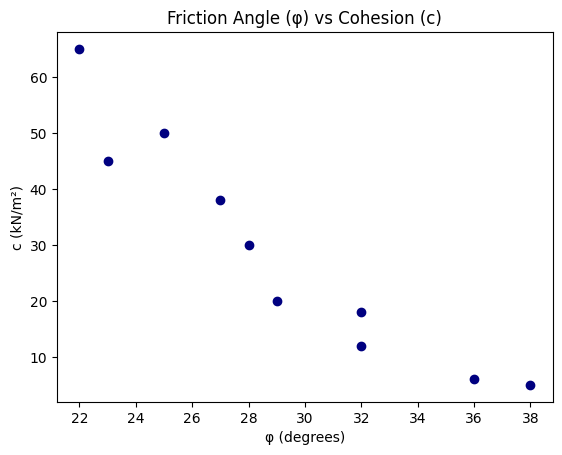

In [6]:
import numpy as np
#import pandas as pd
import matplotlib.pyplot as plt
#from scipy.stats import pearsonr

##store data in numpy arrays
phi = np.array([25, 22, 32, 29, 28, 38, 36, 32, 27, 23])
cohesion = np.array([50, 65, 18, 20, 30, 5, 6, 12, 38, 45])

##plot data
plt.scatter(phi, cohesion, color='navy')

plt.title("Friction Angle (φ) vs Cohesion (c)")
plt.xlabel("φ (degrees)")
plt.ylabel("c (kN/m²)")

plt.show()

##the plot indicates a strong negative correlation


In [7]:
from scipy.stats import pearsonr

##calculate correlation coefficient and p-value using the Pearson coefficient, r.
r, pvalue = pearsonr(phi, cohesion)

print("The correlation coefficient is", r, "with a p-value of", pvalue)

##-0.945 is really close to -1, so there seems to be a strong negative linear correlation between phi and cohesion.
##the p-value of 0.0000374... is much smaller that 0.05, indicating the correlation is statistically significant.
##this supports the initial conclusion of a negative correlation base on the scatter plot.


The correlation coefficient is -0.945014965790795 with a p-value of 3.741175599326274e-05


### Question 4.8
Monthly landslide frequency in a mountain region is documented in a histogram (Fig. 4.53). The question is whether there is a cyclic pattern or seasonal trend in landslide occurrence. Outline a method to determine if the observed frequencies are random or exhibit significant seasonality.


In [ ]:
# Hints and Starting Code for Question 4.8

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Approach Hints:
# 1. Represent the monthly frequency data in a time series format.
# 2. Use time-series analysis, e.g., seasonal_decompose from statsmodels, to detect seasonality.
# 3. Alternatively, consider hypothesis tests for randomness or periodicity (e.g. autocorrelation plots).
# 4. Visualize the data to check for any repeating patterns across months or seasons.


31


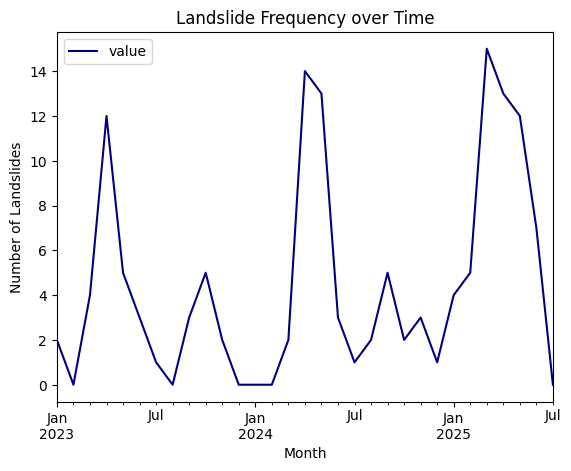

In [18]:
#import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#from statsmodels.tsa.seasonal import seasonal_decompose

##build pandas dataframe for histogram data
months = pd.date_range(start='2023-01-01', end='2025-07-01', freq='MS')
#print(len(months))
data = np.array([2,0,4,12,5,3,1,0,3,5,2,0,0,0,2,14,13,3,1,2,5,2,3,1,4,5,15,13,12,7,0])
print(len(data))

landslides = pd.DataFrame({'value': data}, index=months)
#print(landslides)

##plot time series
landslides.plot(color='navy')

plt.title("Landslide Frequency over Time")
plt.xlabel("Month")
plt.ylabel("Number of Landslides")

plt.show()

##the histogram and the time series plot indicate there is a seasonality to landslide frequencies
##spring appears to have a higher occurrance of landslides than any other time of the year with fall having a smaller fequency peak
##there could also be a cyclical trend from year to year as the peak frequency and number of months with greater than 10 landslides appears to increase through time
##more data would be needed to fully analyze the possible cyclical trend


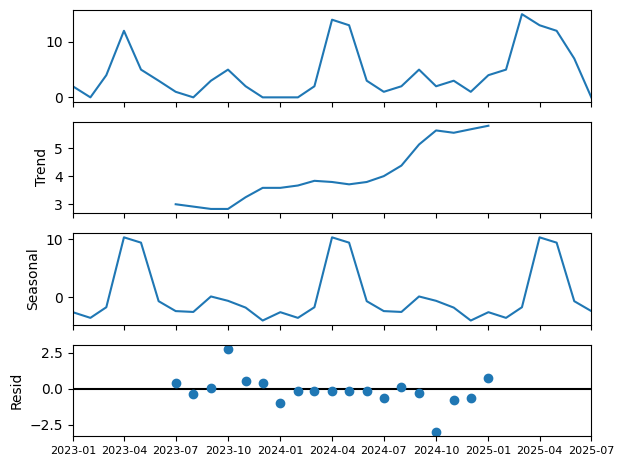

In [27]:
from statsmodels.tsa.seasonal import seasonal_decompose
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

##decompose the data
sdecomp = seasonal_decompose(landslides, period=12)

##plot the decomposition
plots = sdecomp.plot()

for ax in plots.axes:
  ax.tick_params(axis='x', labelsize=8)

plt.show()

##the top plot is the raw data
##the trend does show an increase over time, but we need more data to confirm
##there does appear to be a seaonal trend, with more landslides resulting in the spring months (MAM)
##there appears to be more "noise" around October


### Question 4.9
Two boreholes have been drilled on opposite sides of a fault. The objective is to reconstruct the vertical displacement across the fault. Direct markers are lacking, but variations in mean chlorite content (Fig. 4.54) may provide an indirect measure of displacement. Propose a strategy to use cross-correlation of chlorite content profiles to estimate the fault offset. Discuss any assumptions about continuity and variability of the chlorite data in the subsurface.


In [ ]:
# Hints and Starting Code for Question 4.9

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import correlate

# Approach Hints:
# 1. Represent each borehole's chlorite content profile as a 1D series of numeric values at depth intervals.
# 2. Use the scipy.signal.correlate function to compute cross-correlation between the two profiles.
# 3. Identify the lag (depth shift) that maximizes correlation as an estimate of displacement.
# 4. Carefully consider sampling intervals, data resolution, and boundary effects.


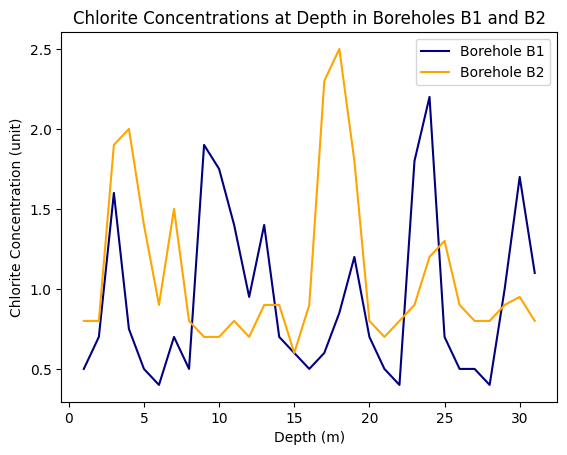

In [33]:
import numpy as np
#import pandas as pd
import matplotlib.pyplot as plt
#from scipy.signal import correlate

##create array for depth
depth = np.arange(1,32)
#print(len(depth))

##create arrays for B1 and B2
b1 = np.array([0.5, 0.7, 1.6, 0.75, 0.5, 0.4, 0.7, 0.5, 1.9, 1.75, 1.4, 0.95, 1.4, 0.7, 0.6, 0.5, 0.6, 0.85, 1.2, 0.7, 0.5, 0.4, 1.8, 2.2, 0.7, 0.5, 0.5, 0.4, 1.0, 1.7, 1.1])
#print(len(b1))
b2 = np.array([0.8, 0.8, 1.9, 2.0, 1.4, 0.9, 1.5, 0.8, 0.7, 0.7, 0.8, 0.7, 0.9, 0.9, 0.6, 0.9, 2.3, 2.5, 1.8, 0.8, 0.7, 0.8, 0.9, 1.2, 1.3, 0.9, 0.8, 0.8, 0.9, 0.95, 0.8])
#print(len(b2))

##plot series together
plt.plot(depth, b1, color='navy', label="Borehole B1")
plt.plot(depth, b2, color='orange', label='Borehole B2')

plt.legend()

plt.title("Chlorite Concentrations at Depth in Boreholes B1 and B2")
plt.xlabel("Depth (m)")
plt.ylabel("Chlorite Concentration (unit)")

plt.show()


B2 lags B1 by 6 m


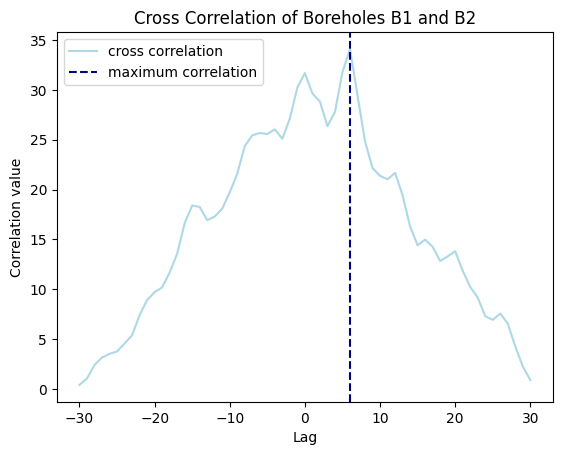

In [47]:
from scipy import signal

##calculate cross-correlation
corr = signal.correlate(b1, b2, mode='full')

##calculate lags
lags = signal.correlation_lags(b1.size, b2.size, mode='full')

maxCorr = np.argmax(corr)
maxCorrLag = lags[maxCorr]

print("B2 lags B1 by", maxCorrLag, "m")

plt.plot(lags, corr, color='lightblue', label='cross correlation')

plt.axvline(x=maxCorrLag, color='navy', linestyle='--', label='maximum correlation')

plt.legend()

plt.title('Cross Correlation of Boreholes B1 and B2')
plt.xlabel('Lag')
plt.ylabel('Correlation value')

plt.show()

##the fault offset is approximately 6m
##this assumes the chlorite concentration was distributed uniformly
##this also assumes the chlorite concentration has not been altered since deposition or was evenly altered


### Question 4.10
A medieval copper mine site is being converted into residential housing, and evidence of ancient copper contamination is expected. Sea thrift (Armeria maritima) is an indicator plant for copper, so its presence was recorded along a profile in 20 m × 20 m squares. The observed shoot counts are:  
3, 5, 11, 12, 8, 19, 22, 18, 11, 13  

An experimental semivariogram is to be derived from these data as a preliminary spatial analysis. Outline how you would compute and plot a semivariogram for these shoot counts, and discuss what patterns in spatial variability might imply for copper contamination distribution.


In [ ]:
# Hints and Starting Code for Question 4.10

import numpy as np
import matplotlib.pyplot as plt

# Approach Hints:
# 1. Arrange the shoot counts in spatial order (e.g., as a function of distance along the profile).
# 2. Calculate pairwise distances between measurement points (assuming each square is at intervals of 20 m).
# 3. Compute the semivariogram γ(h) = 0.5 * mean[ (Z(x) - Z(x+h))^2 ] for each distance bin h.
# 4. Plot the semivariogram (γ on the y-axis vs. distance h on the x-axis) to see if there's any spatial structure.
# 5. Look for a sill, range, or nugget effect that might indicate how contamination (and thus sea thrift) is distributed.


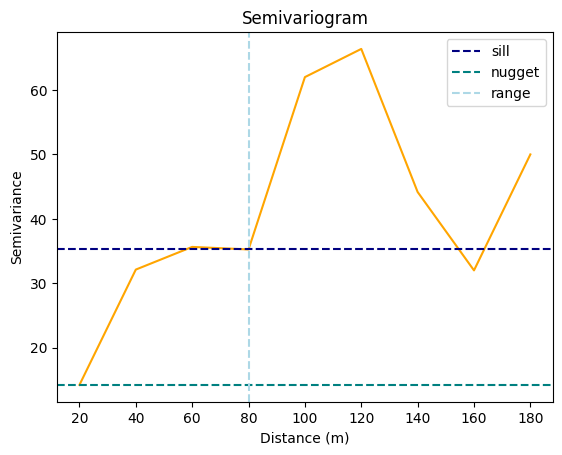

In [95]:
import numpy as np
import matplotlib.pyplot as plt

##create arrays for spacing and shoot counts
spacing = np.arange(0, 181, 20)
#print(len(spacing))
shootCounts = np.array([3,5,11,12,8,19,22,18,11,13])
#print(len(shootCounts))
lags = np.array([1,2,3,4,5,6])

##calculate pairwise distances and semivariance
gamma = []

for j in range(1, len(shootCounts)):
  sqDiffSum = 0
  for i in range(len(shootCounts)-j):
    sqDiffSum += (shootCounts[i] - shootCounts[i+j])**2
  g = (1/(2*(len(shootCounts)-j)))*sqDiffSum
  gamma.append(float(g))

#print(gamma)

plt.plot(spacing[1:], gamma, color="orange")

plt.axhline(y=gamma[3], color='navy', linestyle='--', label='sill')
plt.axhline(y=min(gamma), color='teal', linestyle='--', label='nugget')

plt.axvline(x=spacing[4], color='lightblue', linestyle='--', label='range')

plt.legend()

plt.title('Semivariogram')
plt.xlabel('Distance (m)')
plt.ylabel('Semivariance')

plt.show()

##uncorrelated to the right of the range


In [79]:
#shootCounts = np.array([3,5,11,12,8,19,22,18,11,13])

##for 20m
#sqDiffSum = 0

#for i in range(len(shootCounts)-1):
  #sqDiffSum += (shootCounts[i] - shootCounts[i+1])**2

#gamma20 = (1/(2*(len(shootCounts)-1)))*sqDiffSum
#print(gamma20)


##for 40m
#sqDiffSum40 = 0

#for i in range(len(shootCounts)-2):
  #sqDiffSum40 += (shootCounts[i] - shootCounts[i+2])**2

#gamma40 = (1/(2*(len(shootCounts)-2)))*sqDiffSum40
#print(gamma40)

##for 60m
#sqDiffSum60 = 0

#for i in range(len(shootCounts)-3):
  #sqDiffSum60 += (shootCounts[i] - shootCounts[i+3])**2

#gamma60 = (1/(2*(len(shootCounts)-3)))*sqDiffSum60
#print(gamma60)


# Question 4.11

The following rock sequences are encountered in exploratory drilling:

- Claystone (C)  
- Conglomerate (K)  
- Sandstone (S)  
- Siltstone (U)

(See Table 4.5 for the per-meter breakdown.)

**Task:**  
1. What is the probability that conglomerate (K) will be drilled again in the *next* meter of drilling?  
2. What is the probability that conglomerate will be drilled again in the *next-but-one* meter of drilling?

You may assume that the encountered rock types can be treated as sequential observations of a Markov process or using simpler independence assumptions (depending on your interpretation of the problem’s statement).

In [69]:
# Use this cell to start setting up your approach in Python.
# Possible steps:
# 1. Represent the rock sequences as a list or array.
# 2. Construct transition probabilities from the data if needed.
# 3. Calculate probabilities for "next meter" and "next-but-one meter."

import numpy as np

# HINT:
# - If you treat each meter drilled as a step in a Markov chain, you need a 4x4 transition matrix
#   (C, K, S, U) or some simpler approach based on frequencies.
# - Probability that K appears next might come directly from the row in the matrix corresponding
#   to the current rock type.
# - For the 'next-but-one' question, you might multiply transition matrices (e.g., T^2).


In [51]:
import numpy as np

seq = ['U','S','K','S','S','K','K','C','U','S','K','S','S','K','C','U','S','S','S','K','K','K','U']
#print(len(seq))
states = ['C', 'K', 'S', 'U']
stateToIndex = {s: i for i, s in enumerate(states)}
n = len(states)

##count transitions
counts = np.zeros((n, n))

for i in range(len(seq) - 1):
  current = stateToIndex[seq[i]]
  next = stateToIndex[seq[i+1]]
  counts[current, next] += 1

#print(counts)

##calculate transition probabilities
transMatrix = np.zeros((n,n))

for i in range(n):
  rsum = np.sum(counts[i])
  if rsum > 0:
    transMatrix[i] = counts[i]/rsum

currentIndex = stateToIndex[seq[-1]]
kIndex = stateToIndex['K']

probKNext = transMatrix[currentIndex, kIndex]
print("The probability of K being drilled in the next meter =", probKNext)

p2 = np.dot(transMatrix, transMatrix)
probKNBO = p2[currentIndex, kIndex]
print("The probability of K being drilled in the next but one meter =", probKNBO)


The probability of K being drilled in the next meter = 0.0
The probability of K being drilled in the next but one meter = 0.5555555555555556


In [52]:
#seq = ['U','S','K','S','S','K','K','C','U','S','K','S','S','K','C','U','S','S','S','K','K','K','U']
#print(len(seq))
#states = ['C', 'K', 'S', 'U']
#n = len(states)
#s = 1 + n
#print(range(len(n)))


# Question 4.12

The following orientation data (dip direction α / dip β) for bedding planes are recorded (n=14):

123/25, 147/22, 120/24, 111/24, 142/26, 133/27, 135/22, 156/21,  
110/25, 101/25, 133/20, 123/22, 145/25, 126/24

**Task:**  
1. Determine the mean resultant length.  
2. Determine the dip direction and dip of the mean vector.  
3. Determine the spherical standard deviation and the spherical confidence interval of the mean vector for an error probability of α = 0.1.

In [ ]:
# Use this cell to load and process the orientation data.
# HINT:
# 1. Convert the dip direction/dip pairs into unit vectors in 3D space.
# 2. Sum these vectors, and derive the resultant direction and magnitude.
# 3. Calculate relevant statistics (standard deviation, confidence intervals) on a sphere.

import numpy as np

# Example structure:
# data = [(123,25), (147,22), (120,24), ...]
# Then convert each (alpha, beta) to x,y,z components on the unit sphere.
# Summation and geometry yield the mean vector direction and length.
#
# You might consider using spherical to Cartesian conversions:
# x = cos(dip) * sin(direction)
# y = cos(dip) * cos(direction)
# z = sin(dip)
# (in radians)


In [36]:
import numpy as np
import math

##create array for dip direction and dip
alpha = np.array([123,147,120,111,142,133,135,156,110,101,133,123,145,126], dtype=float)
for i in range(len(alpha)):
  alpha[i] = math.radians(alpha[i])
#print(len(alpha))
beta = np.array([25,22,24,24,26,27,22,21,25,25,20,22,25,24], dtype=float)
for i in range(len(beta)):
  beta[i] = math.radians(beta[i])
#print(len(beta))

##spherical to cartesian conversions
x = []
y = []
z = []

for i in range(len(alpha)):
  ex = math.cos(beta[i]) * math.cos(alpha[i])
  why = math.cos(beta[i]) * math.sin(alpha[i])
  zed = math.sin(beta[i])

  x.append(ex)
  y.append(why)
  z.append(zed)

X = np.sum(x)
Y = np.sum(y)
Z = np.sum(z)

resultant = math.sqrt(X**2 + Y**2 + Z**2)
#print("The resultant length =", resultant)

meanLength = resultant / len(alpha)
print("The mean resultant length =", meanLength)

meanAlpha = math.degrees(math.atan2(Y, X))
print("The mean dip direction =", meanAlpha)

meanBeta = math.degrees(math.asin(Z/resultant))
print("The mean dip =", meanBeta)

##calculate spherical standard deviation
k = (len(alpha)-1)/(len(alpha)-resultant)
s = 81/math.sqrt(k)
print("The spherical standard deviation =", s)

##calculate spherical confidence interval
cosTheta = 1 - ((len(alpha)-resultant)/resultant)*((1/0.1)**(1/(len(alpha)-1))-1)
sci = math.degrees(math.acos(cosTheta))
print("The 90% spherical confidence interval =", sci)


The mean resultant length = 0.9708928440790123
The mean dip direction = 129.00807733386785
The mean dip = 24.45616102018309
The spherical standard deviation = 14.340927713705378
The 90% spherical confidence interval = 6.178926819326725


In [35]:
#import math
#import numpy as np

#a = 123
#arad = math.radians(a)
#b = 25
#brad = math.radians(b)

#ex = math.cos(brad)*math.cos(arad)
#print(ex)
#why = math.cos(brad)*math.sin(arad)
#print(why)
#zed = math.sin(brad)
#print(zed)

#alpha = np.array([123,147,120,111,142,133,135,156,110,101,133,123,145,126], dtype=float)
#for i in range(len(alpha)):
  #alpha[i] = math.radians(alpha[i])

#print(alpha)
